# **Laboratorio 12: 🚀 Despliegue 🚀**

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Damián De Aguiar
- Nombre de alumno 2: Angelo León Gianoni

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/damiatus/labPrograCientifica/tree/main)

## Temas a tratar

- Entrenamiento y registro de modelos usando MLFlow.
- Despliegue de modelo usando FastAPI
- Containerización del proyecto usando Docker

## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Generar una solución a un problema a partir de ML
- Desplegar su solución usando MLFlow, FastAPI y Docker

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# **Introducción**

<p align="center">
  <img src="https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExODJnMHJzNzlkNmQweXoyY3ltbnZ2ZDlxY2c0aW5jcHNzeDNtOXBsdCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AbPdhwsMgjMjax5reo/giphy.gif" width="400">
</p>



Consumida en la tristeza el despido de Renacín, Smapina ha decaído en su desempeño, lo que se ha traducido en un irregular tratamiento del agua. Esto ha implicado una baja en la calidad del agua, llegando a haber algunos puntos de la comuna en la que el vital elemento no es apto para el consumo humano. Es por esto que la sanitaria pública de la municipalidad de Maipú se ha contactado con ustedes para que le entreguen una urgente solución a este problema (a la vez que dejan a Smapina, al igual que Renacín, sin trabajo 😔).

El problema que la empresa le ha solicitado resolver es el de elaborar un sistema que les permita saber si el agua es potable o no. Para esto, la sanitaria les ha proveido una base de datos con la lectura de múltiples sensores IOT colocados en diversas cañerías, conductos y estanques. Estos sensores señalan nueve tipos de mediciones químicas y más una etiqueta elaborada en laboratorio que indica si el agua es potable o no el agua.

La idea final es que puedan, en el caso que el agua no sea potable, dar un aviso inmediato para corregir el problema. Tenga en cuenta que parte del equipo docente vive en Maipú y su intoxicación podría implicar graves problemas para el cierre del curso.

Atributos:

1. pH value
2. Hardness
3. Solids (Total dissolved solids - TDS)
4. Chloramines
5. Sulfate
6. Conductivity
7. Organic_carbon
8. Trihalomethanes
9. Turbidity

Variable a predecir:

10. Potability (1 si es potable, 0 no potable)

Descripción de cada atributo se pueden encontrar en el siguiente link: [dataset](https://www.kaggle.com/adityakadiwal/water-potability)

# **1. Optimización de modelos con Optuna + MLFlow (2.0 puntos)**

El objetivo de esta sección es que ustedes puedan combinar Optuna con MLFlow para poder realizar la optimización de los hiperparámetros de sus modelos.

Como aún no hemos hablado nada sobre `MLFlow` cabe preguntarse: **¡¿Qué !"#@ es `MLflow`?!**

<p align="center">
  <img src="https://media.tenor.com/eusgDKT4smQAAAAC/matthew-perry-chandler-bing.gif" width="400">
</p>

## **MLFlow**

`MLflow` es una plataforma de código abierto que simplifica la gestión y seguimiento de proyectos de aprendizaje automático. Con sus herramientas, los desarrolladores pueden organizar, rastrear y comparar experimentos, además de registrar modelos y controlar versiones.

<p align="center">
  <img src="https://spark.apache.org/images/mlflow-logo.png" width="350">
</p>

Si bien esta plataforma cuenta con un gran número de herramientas y funcionalidades, en este laboratorio trabajaremos con dos:
1. **Runs**: Registro que constituye la información guardada tras la ejecución de un entrenamiento. Cada `run` tiene su propio run_id, el cual sirve como identificador para el entrenamiento en sí mismo. Dentro de cada `run` podremos acceder a información como los hiperparámetros utilizados, las métricas obtenidas, las librerías requeridas y hasta nos permite descargar el modelo entrenado.
2. **Experiments**: Se utilizan para agrupar y organizar diferentes ejecuciones de modelos (`runs`). En ese sentido, un experimento puede agrupar 1 o más `runs`. De esta manera, es posible también registrar métricas, parámetros y archivos (artefactos) asociados a cada experimento.

### **Todo bien pero entonces, ¿cómo se usa en la práctica `MLflow`?**

Es sencillo! Considerando un problema de machine learning genérico, podemos registrar la información relevante del entrenamiento ejecutando `mlflow.autolog()` antes entrenar nuestro modelo. Veamos este bonito ejemplo facilitado por los mismos creadores de `MLflow`:

```python
#!pip install mlflow
import mlflow # importar mlflow

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor

db = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(db.data, db.target)

# Create and train models.
rf = RandomForestRegressor(n_estimators=100, max_depth=6, max_features=3)

mlflow.autolog() # registrar automáticamente información del entrenamiento
with mlflow.start_run(): # delimita inicio y fin del run
    # aquí comienza el run
    rf.fit(X_train, y_train) # train the model
    predictions = rf.predict(X_test) # Use the model to make predictions on the test dataset.
    # aquí termina el run
```

Si ustedes ejecutan el código anterior en sus máquinas locales (desde un jupyter notebook por ejemplo) se darán cuenta que en su directorio *root* se ha creado la carpeta `mlruns`. Esta carpeta lleva el tracking de todos los entrenamientos ejecutados desde el directorio root (importante: si se cambian de directorio y vuelven a ejecutar el código anterior, se creará otra carpeta y no tendrán acceso al entrenamiento anterior). Para visualizar estos entrenamientos, `MLflow` nos facilita hermosa interfaz visual a la que podemos acceder ejecutando:

```
mlflow ui
```

y luego pinchando en la ruta http://127.0.0.1:5000 que nos retorna la terminal. Veamos en vivo algunas de sus funcionalidades!

<p align="center">
  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExZXVuM3A5MW1heDFpa21qbGlwN2pyc2VoNnZsMmRzODZxdnluemo2bCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/3o84sq21TxDH6PyYms/giphy.gif" width="400">
</p>

Les dejamos también algunos comandos útiles:

- `mlflow.create_experiment("nombre_experimento")`: Les permite crear un nuevo experimento para agrupar entrenamientos
- `mlflow.log_metric("nombre_métrica", métrica)`: Les permite registrar una métrica *custom* bajo el nombre de "nombre_métrica"


## **1.1 Combinando Optuna + MLflow (2.0 puntos)**

Ahora que tenemos conocimiento de ambas herramientas, intentemos ahora combinarlas para **más sabor**. El objetivo de este apartado es simple: automatizar la optimización de los parámetros de nuestros modelos usando `Optuna` y registrando de forma automática cada resultado en `MLFlow`.

Considerando el objetivo planteado, se le pide completar la función `optimize_model`, la cual debe:
- **Optimizar los hiperparámetros del modelo `XGBoost` usando `Optuna`.**
- **Registrar cada entrenamiento en un experimento nuevo**, asegurándose de que la métrica `f1-score` se registre como `"valid_f1"`. No se deben guardar todos los experimentos en *Default*; en su lugar, cada `experiment` y `run` deben tener nombres interpretables, reconocibles y diferentes a los nombres por defecto (por ejemplo, para un run: "XGBoost con lr 0.1").
- **Guardar los gráficos de Optuna** dentro de una carpeta de artefactos de Mlflow llamada `/plots`.
- **Devolver el mejor modelo** usando la función `get_best_model` y serializarlo en el disco con `pickle.dump`. Luego, guardar el modelo en la carpeta `/models`.
- **Guardar el código en `optimize.py`**. La ejecución de `python optimize.py` debería ejecutar la función `optimize_model`.
- **Guardar las versiones de las librerías utilizadas** en el desarrollo.
- **Respalde las configuraciones del modelo final y la importancia de las variables** en un gráfico dentro de la carpeta `/plots` creada anteriormente.

*Hint: Le puede ser útil revisar los parámetros que recibe `mlflow.start_run`*

```python
def get_best_model(experiment_id):
    runs = mlflow.search_runs(experiment_id)
    best_model_id = runs.sort_values("metrics.valid_f1")["run_id"].iloc[0]
    best_model = mlflow.sklearn.load_model("runs:/" + best_model_id + "/model")

    return best_model
```

In [3]:
#from google.colab import drive
import pandas as pd
#drive.mount('/content/drive')

file_path = '/content/drive/My Drive/LabdeProgra/Lab 12'
file_path = ''
df = pd.read_csv(file_path + "./water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
#!pip install optuna mlflow
#!pip install -U kaleido

In [7]:
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
import uvicorn
import optuna
import mlflow
import mlflow.xgboost
import xgboost as xgb
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
import sys
import sklearn

In [ ]:
# 1:

code = """
import pandas as pd
import optuna
import mlflow
import mlflow.xgboost
import xgboost as xgb
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
import sys
import sklearn

file_path = ''
df = pd.read_csv(file_path + "./water_potability.csv")

X = df.drop(columns=["Potability"])
y = df["Potability"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=20676305)

def get_best_model(experiment_id):
    runs = mlflow.search_runs(experiment_id)
    best_model_id = runs.sort_values("metrics.valid_f1")["run_id"].iloc[0]
    best_model = mlflow.sklearn.load_model("runs:/" + best_model_id + "/model")
    return best_model

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300)
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_valid)
    valid_f1 = f1_score(y_valid, preds, average='macro')

    with mlflow.start_run(run_name=f"XGBoost con lr {params['learning_rate']}"):
        mlflow.sklearn.log_model(model, "model")
        mlflow.log_param('learning_rate', params['learning_rate'])
        mlflow.log_param('max_depth', params['max_depth'])
        mlflow.log_param('subsample', params['subsample'])
        mlflow.log_param('colsample_bytree', params['colsample_bytree'])
        mlflow.log_param('n_estimators', params['n_estimators'])
        mlflow.log_metric('valid_f1', valid_f1)

    return valid_f1

def optimize_model():
    base_path = '/content/drive/My Drive/LabdeProgra/Lab 12'

    mlflow.set_experiment("XGBoost Optimization")

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30)

    def log_libraries_versions():
        with open(base_path + "/libs_versions.txt", 'w') as f:
            f.write(f"Python version: {sys.version}\\n")
            f.write(f"optuna version: {optuna.__version__}\\n")
            f.write(f"mlflow version: {mlflow.__version__}\\n")
            f.write(f"xgboost version: {xgb.__version__}\\n")
            f.write(f"scikit-learn version: {sklearn.__version__}\\n")

        mlflow.set_tag("python_version", sys.version)
        mlflow.set_tag("optuna_version", optuna.__version__)
        mlflow.set_tag("mlflow_version", mlflow.__version__)
        mlflow.set_tag("xgboost_version", xgb.__version__)
        mlflow.set_tag("sklearn_version", sklearn.__version__)

    with mlflow.start_run():
        log_libraries_versions()
        best_model = get_best_model(mlflow.active_run().info.experiment_id)
        model_path = os.path.join(base_path, 'models', 'best_model.pkl')
        os.makedirs(os.path.dirname(model_path), exist_ok=True)
        with open(model_path, 'wb') as f:
            pickle.dump(best_model, f)

        os.makedirs(os.path.join(base_path, 'plots'), exist_ok=True)
        fig_optimization = plot_optimization_history(study)
        fig_optimization.figure.savefig(os.path.join(base_path, 'plots', 'optimization_history.png'))

        fig_importances = plot_param_importances(study)
        fig_importances.figure.savefig(os.path.join(base_path, 'plots', 'param_importances.png'))

        mlflow.log_artifact(os.path.join(base_path, 'plots', 'optimization_history.png'), artifact_path='plots')
        mlflow.log_artifact(os.path.join(base_path, 'plots', 'param_importances.png'), artifact_path='plots')

        fig, ax = plt.subplots()
        xgb.plot_importance(best_model, ax=ax)
        plt.savefig(os.path.join(base_path, 'plots', 'variable_importances.png'))
        mlflow.log_artifact(os.path.join(base_path, 'plots', 'variable_importances.png'), artifact_path='plots')

if __name__ == '__main__':
    optimize_model()
"""

#with open("/content/drive/My Drive/LabdeProgra/Lab 12/optimize.py", "w") as file:
#    file.write(code)

with open("./optimize.py", "w") as file:
    file.write(code)

# **2. FastAPI (2.0 puntos)**

<div align="center">
  <img src="https://media3.giphy.com/media/YQitE4YNQNahy/giphy-downsized-large.gif" width="500">
</div>

Con el modelo ya entrenado, la idea de esta sección es generar una API REST a la cual se le pueda hacer *requests* para así interactuar con su modelo. En particular, se le pide:

- Guardar el código de esta sección en el archivo `main.py`. Note que ejecutar `python main.py` debería levantar el servidor en el puerto por defecto.
- Defina `GET` con ruta tipo *home* que describa brevemente su modelo, el problema que intenta resolver, su entrada y salida.
- Defina un `POST` a la ruta `/potabilidad/` donde utilice su mejor optimizado para predecir si una medición de agua es o no potable. Por ejemplo, una llamada de esta ruta con un *body*:

```json
{
   "ph":10.316400384553162,
   "Hardness":217.2668424334475,
   "Solids":10676.508475429378,
   "Chloramines":3.445514571005745,
   "Sulfate":397.7549459751925,
   "Conductivity":492.20647361771086,
   "Organic_carbon":12.812732207582542,
   "Trihalomethanes":72.28192021570328,
   "Turbidity":3.4073494284238364
}
```

Su servidor debería retornar una respuesta HTML con código 200 con:


```json
{
  "potabilidad": 0 # respuesta puede variar según el clasificador que entrenen
}
```

**`HINT:` Recuerde que puede utilizar [http://localhost:8000/docs](http://localhost:8000/docs) para hacer un `POST`.**

In [ ]:
#!pip install "fastapi[all]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.1/442.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.2/168.2 kB 14.2 MB/s eta 0:00:00


In [10]:
# 2:

code = """
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
import uvicorn

app = FastAPI()

class WaterQualityData(BaseModel):
    ph: float
    Hardness: float
    Solids: float
    Chloramines: float
    Sulfate: float
    Conductivity: float
    Organic_carbon: float
    Trihalomethanes: float
    Turbidity: float

model_path = "/content/drive/My Drive/LabdeProgra/Lab 12/models/best_model.pkl"
with open(model_path, 'rb') as model_file:
    best_model = pickle.load(model_file)

@app.get("/")
def read_root():
    return {
        "description": "Este modelo predice si una medición de agua es potable o no, utilizando características fisicoquímicas del agua.",
        "problem": "Clasificación binaria: determinar si el agua es potable (1) o no potable (0).",
        "input": {
            "ph": "pH del agua",
            "Hardness": "Dureza del agua",
            "Solids": "Sólidos totales disueltos",
            "Chloramines": "Concentración de cloraminas",
            "Sulfate": "Concentración de sulfatos",
            "Conductivity": "Conductividad eléctrica",
            "Organic_carbon": "Carbono orgánico total",
            "Trihalomethanes": "Trihalometanos",
            "Turbidity": "Turbidez"
        },
        "output": {
            "potabilidad": "0 (no potable) o 1 (potable)"
        }
    }

@app.post("/potabilidad/")
def predict_water_quality(data: WaterQualityData):
    input_data = np.array([[
        data.ph,
        data.Hardness,
        data.Solids,
        data.Chloramines,
        data.Sulfate,
        data.Conductivity,
        data.Organic_carbon,
        data.Trihalomethanes,
        data.Turbidity
    ]])

    prediction = best_model.predict(input_data)
    return {"potabilidad": int(prediction[0])}

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)
"""

#with open("/content/drive/My Drive/LabdeProgra/Lab 12/main.py", "w") as file:
  #  file.write(code)

with open("./main.py", "w") as file:
    file.write(code)

Mostramos el servidor corriendo y sindo probado

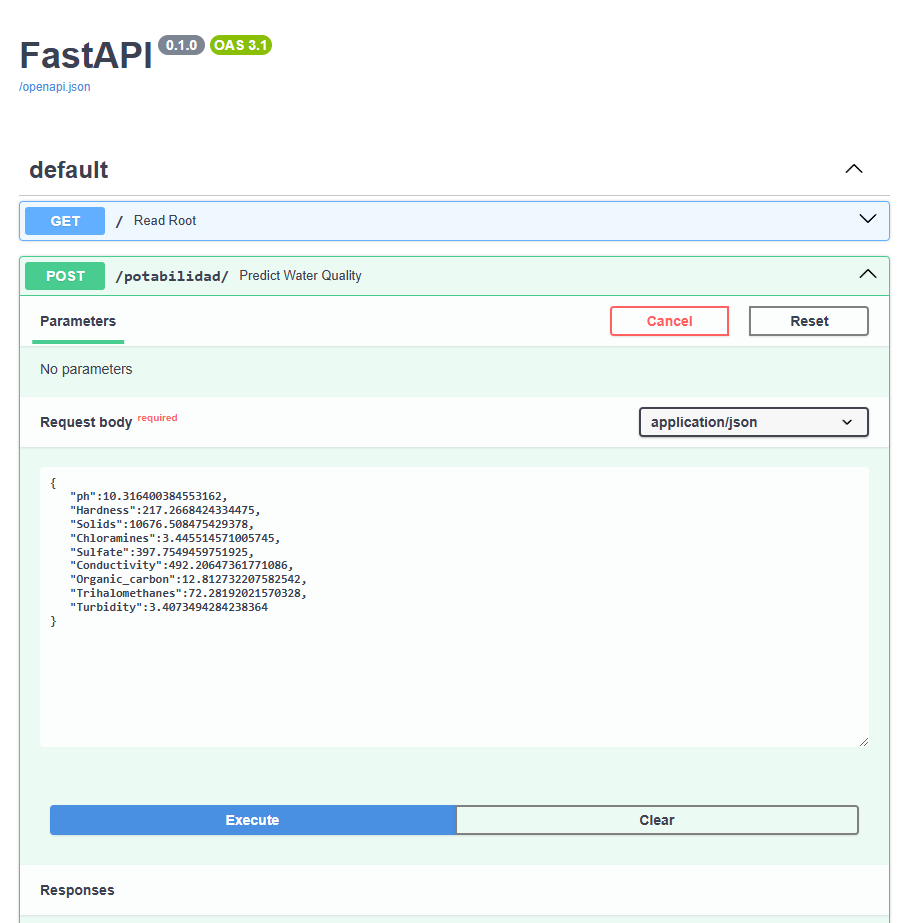

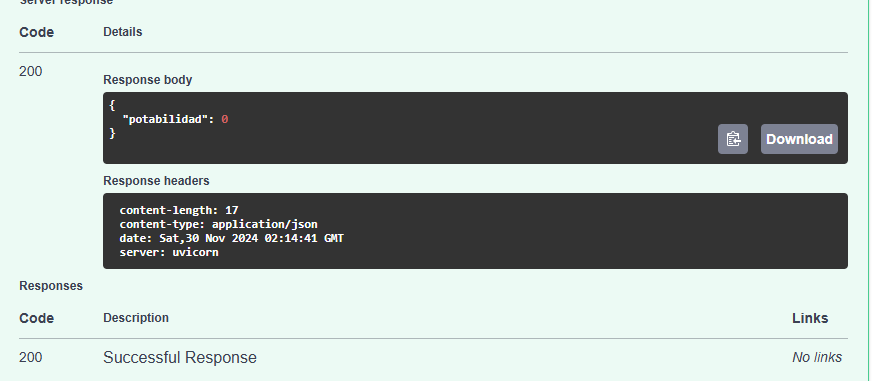

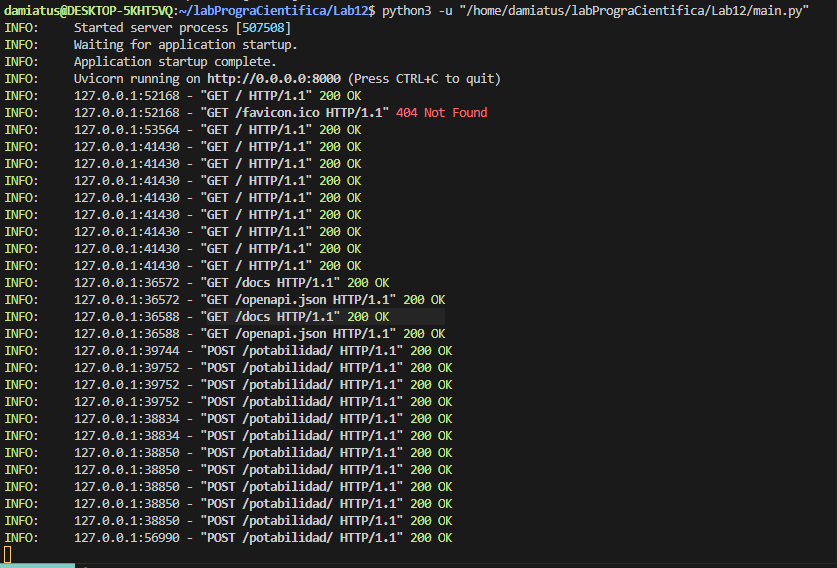

# **3. Docker (2 puntos)**

<div align="center">
  <img src="https://miro.medium.com/v2/resize:fit:1400/1*9rafh2W0rbRJIKJzqYc8yA.gif" width="500">
</div>

Tras el éxito de su aplicación web para generar la salida, Smapina le solicita que genere un contenedor para poder ejecutarla en cualquier computador de la empresa de agua potable.

## **3.1 Creación de Container (1 punto)**

Cree un Dockerfile que use una imagen base de Python, copie los archivos del proyecto e instale las dependencias desde un `requirements.txt`. Con esto, construya y ejecute el contenedor Docker para la API configurada anteriormente. Entregue el código fuente (incluyendo `main.py`, `requirements.txt`, y `Dockerfile`) y la imagen Docker de la aplicación. Para la dockerización, asegúrese de cumplir con los siguientes puntos:

1. **Generar un archivo `.dockerignore`** que ignore carpetas y archivos innecesarios dentro del contenedor.
2. **Configurar un volumen** que permita la persistencia de los datos en una ruta local del computador.
3. **Exponer el puerto** para acceder a la ruta de la API sin tener que entrar al contenedor directamente.
4. **Incluir imágenes en el notebook** que muestren la ejecución del contenedor y los resultados obtenidos.
5. **Revisar y comentar los recursos utilizados por el contenedor**. Analice si los contenedores son livianos en términos de recursos.

## **3.2 Preguntas de Smapina (1 punto)**
Tras haber experimentado con Docker, Smapina desea profundizar más en el tema y decide realizarle las siguientes consultas:

- ¿Cómo se diferencia Docker de una máquina virtual (VM)?
- ¿Cuál es la diferencia entre usar Docker y ejecutar la aplicación directamente en el sistema local?
- ¿Cómo asegura Docker la consistencia entre diferentes entornos de desarrollo y producción?
- ¿Cómo se gestionan los volúmenes en Docker para la persistencia de datos?
- ¿Qué son Dockerfile y docker-compose.yml, y cuál es su propósito?

1- Los contenedores de Docker son más livianos y rápidos en términos de arranque y ejecución, ya que no requieren cargar un sistema operativo completo como lo hacen las VM. Otra diferencia es que Docker se basa en contenedores que pueden ejecutarse consistentemente en diferentes sistemas operativos siempre que tengan Docker instalado, mientras que las VM dependen del sistema operativo en el que se ejecutan.

2- Al usar Docker, la aplicación se ejecuta en un entorno aislado dentro de un contenedor, lo que significa que no depende de las configuraciones y versiones de librerías del sistema local. Esto evita problemas de compatibilidad que suelen aparecer cuando ejecutas la aplicación directamente en el sistema.

3- Docker aísla la aplicación de las configuraciones y versiones de dependencias del sistema operativo oculto, evitando "errores de entorno". Tambien, las aplicaciones se empaquetan en imágenes de Docker, que incluyen tanto el código como todas sus dependencias. Esto significa que la imagen es la misma en desarrollo, pruebas y producción, lo que asegura que la aplicación funcione de la misma manera en todos los entornos.

4- Volúmenes en Docker son utilizados para persistir datos fuera de los contenedores. Esto es crucial porque cualquier dato almacenado en el sistema de archivos del contenedor se perderá si el contenedor se elimina o se reinicia.

5- Dockerfile es un archivo de texto que contiene instrucciones para construir una imagen de Docker. Cada línea en un Dockerfile representa un comando que se ejecuta para ensamblar la imagen final. Por otro lado, docker-compose.yml es un archivo de configuración utilizado por Docker Compose para definir y gestionar múltiples contenedores a la vez.

Ambos archivos son fundamentales para automatizar el proceso de construcción y despliegue de aplicaciones en contenedores Docker, pero Dockerfile es más específico para la creación de la imagen, mientras que docker-compose.yml gestiona la orquestación de múltiples contenedores.

Requierements

In [ ]:
import importlib
import pkg_resources
import os
import subprocess

# Lista de librerías que estás utilizando
libraries = [
    "pandas",
    "fastapi",
    "pydantic",
    "numpy",
    "uvicorn",
    "optuna",
    "mlflow",
    "xgboost", 
    "matplotlib",
    "sklearn",
]

# Ruta donde se guardará el archivo requirements.txt
output_path = "/content/drive/My Drive/LabdeProgra/Lab 12/requirements.txt"

# Crear o sobrescribir el archivo requirements.txt
with open(output_path, 'w') as f:
    for lib in libraries:
        try:
            # Intentar obtener el módulo y la versión instalada
            version = pkg_resources.get_distribution(lib).version
            f.write(f"{lib}=={version}\n")
        except pkg_resources.DistributionNotFound:
            print(f"No se pudo encontrar la versión para '{lib}'.")

print(f"requirements.txt ha sido creado en la ruta {output_path}.")

Note: you may need to restart the kernel to use updated packages.


Creamos el contendor:

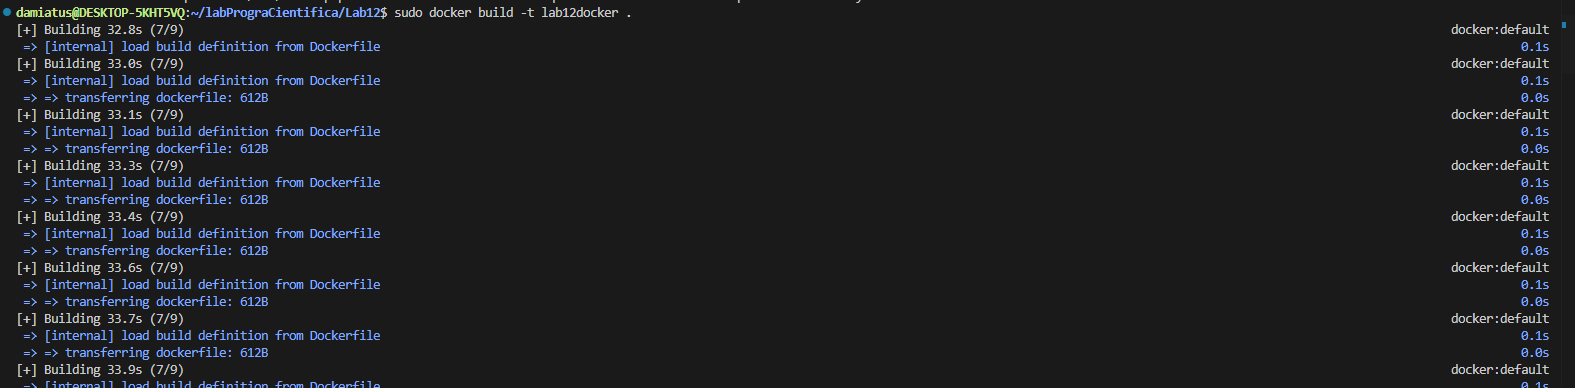

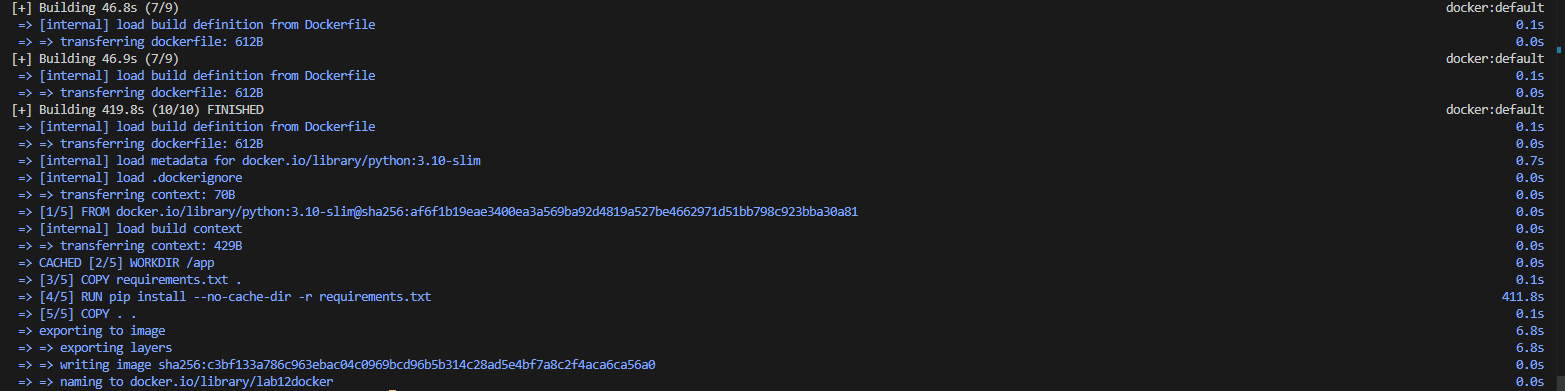

Ejecutamos el contenedor:

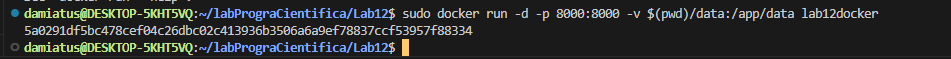

Mostramos que está correindo correctamente:

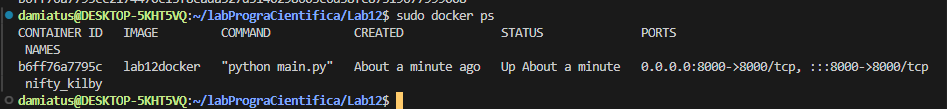

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<div align="center">
  <img src="https://i.pinimg.com/originals/84/5d/f1/845df1aefc6a5e37ae575327a0cc6e43.gif" width="500">
</div>